In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,0,0,0.0025,201,NaN,2639|20639|26563|29364|32165|33939|36675|54811...,1799|19799|23763|26564|29365|32166|34995|53761...
1,1,20,0,0,0.0025,220,NaN,2639|20639|26759|29560|32361|34057|39901|51368...,1799|19799|23959|26760|29561|32362|38221|50318...
2,2,20,1,1,0.0025,207,4420|4422|4424,4439|24396|27197|29998|32639|34320|38083|56611...,3599|21599|24397|27198|29999|32640|36403|55561...
3,3,20,0,0,0.0025,220,NaN,4439|24396|27197|29998|32639|34320|40719|53168...,3599|21599|24397|27198|29999|32640|39039|52118...
4,4,20,1,1,0.0025,220,NaN,6239|24669|27470|30271|32803|34484|39344|59762...,5399|21869|24670|27471|30272|32804|37664|57361...
5,5,20,0,0,0.0025,237,NaN,6239|24610|27411|30212|32767|34448|41533|54968...,5399|21810|24611|27412|30213|32768|39853|53918...
6,6,20,1,1,0.0025,225,NaN,8039|24989|27790|30591|32995|34676|41103|61961...,7199|22189|24990|27791|30592|32996|39423|59161...
7,7,20,0,0,0.0025,242,NaN,8039|24842|27643|30444|32907|34588|42973|56482...,7199|22042|24843|27644|30445|32908|41293|55432...
8,8,20,1,1,0.0025,217,NaN,9839|25227|28028|30829|33138|34819|42245|63761...,8999|22427|25228|28029|30830|33139|40565|60961...
9,9,20,0,0,0.0025,229,NaN,9839|25038|27839|30640|33024|34705|44119|59418...,8999|22238|25039|27840|30641|33025|42991|57232...


In [3]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0     [2639, 20639, 26563, 29364, 32165, 33939, 3667...
1     [2639, 20639, 26759, 29560, 32361, 34057, 3990...
2     [4439, 24396, 27197, 29998, 32639, 34320, 3808...
3     [4439, 24396, 27197, 29998, 32639, 34320, 4071...
4     [6239, 24669, 27470, 30271, 32803, 34484, 3934...
5     [6239, 24610, 27411, 30212, 32767, 34448, 4153...
6     [8039, 24989, 27790, 30591, 32995, 34676, 4110...
7     [8039, 24842, 27643, 30444, 32907, 34588, 4297...
8     [9839, 25227, 28028, 30829, 33138, 34819, 4224...
9     [9839, 25038, 27839, 30640, 33024, 34705, 4411...
10    [11639, 25390, 28191, 30992, 33235, 34916, 434...
11    [11639, 25227, 28042, 30843, 33146, 34827, 458...
12    [13439, 25626, 28427, 31228, 33377, 35058, 441...
13    [13439, 25552, 28353, 31154, 33333, 35014, 476...
14    [15239, 25965, 28766, 31567, 33580, 36215, 459...
15    [15239, 25866, 28667, 31468, 33521, 35202, 494...
16    [17039, 26206, 29007, 31808, 33725, 36990, 477...
17    [17039, 26069, 28870, 31671, 33643, 35324,

In [4]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0     [1799, 19799, 23763, 26564, 29365, 32166, 3499...
1     [1799, 19799, 23959, 26760, 29561, 32362, 3822...
2     [3599, 21599, 24397, 27198, 29999, 32640, 3640...
3     [3599, 21599, 24397, 27198, 29999, 32640, 3903...
4     [5399, 21869, 24670, 27471, 30272, 32804, 3766...
5     [5399, 21810, 24611, 27412, 30213, 32768, 3985...
6     [7199, 22189, 24990, 27791, 30592, 32996, 3942...
7     [7199, 22042, 24843, 27644, 30445, 32908, 4129...
8     [8999, 22427, 25228, 28029, 30830, 33139, 4056...
9     [8999, 22238, 25039, 27840, 30641, 33025, 4299...
10    [10799, 22590, 25391, 28192, 30993, 33236, 419...
11    [10799, 22427, 25242, 28043, 30844, 33147, 447...
12    [12599, 22826, 25627, 28428, 31229, 33378, 431...
13    [12599, 22752, 25553, 28354, 31155, 33334, 465...
14    [14399, 23165, 25966, 28767, 31568, 34535, 449...
15    [14399, 23066, 25867, 28668, 31469, 33522, 483...
16    [16199, 23406, 26207, 29008, 31809, 35310, 467...
17    [16199, 23269, 26070, 28871, 31672, 33644,

In [5]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [6]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [7]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[1799, 19799, 23763, 26564, 29365, 32166, 3499...","[2639, 20639, 26563, 29364, 32165, 33939, 3667...","[0, 2639, 20639, 26563, 29364, 32165, 33939, 3...","[1799, 17160, 3124, 1, 1, 1, 1056, 17086, 7311..."
1,"[1799, 19799, 23959, 26760, 29561, 32362, 3822...","[2639, 20639, 26759, 29560, 32361, 34057, 3990...","[0, 2639, 20639, 26759, 29560, 32361, 34057, 3...","[1799, 17160, 3320, 1, 1, 1, 4164, 10417, 1092..."
2,"[3599, 21599, 24397, 27198, 29999, 32640, 3640...","[4439, 24396, 27197, 29998, 32639, 34320, 3808...","[0, 4439, 24396, 27197, 29998, 32639, 34320, 3...","[3599, 17160, 1, 1, 1, 1, 2083, 17478, 5761, 1..."
3,"[3599, 21599, 24397, 27198, 29999, 32640, 3903...","[4439, 24396, 27197, 29998, 32639, 34320, 4071...","[0, 4439, 24396, 27197, 29998, 32639, 34320, 4...","[3599, 17160, 1, 1, 1, 1, 4719, 11399, 9325, 1..."
4,"[5399, 21869, 24670, 27471, 30272, 32804, 3766...","[6239, 24669, 27470, 30271, 32803, 34484, 3934...","[0, 6239, 24669, 27470, 30271, 32803, 34484, 3...","[5399, 15630, 1, 1, 1, 1, 3180, 18017, 2885, 1..."


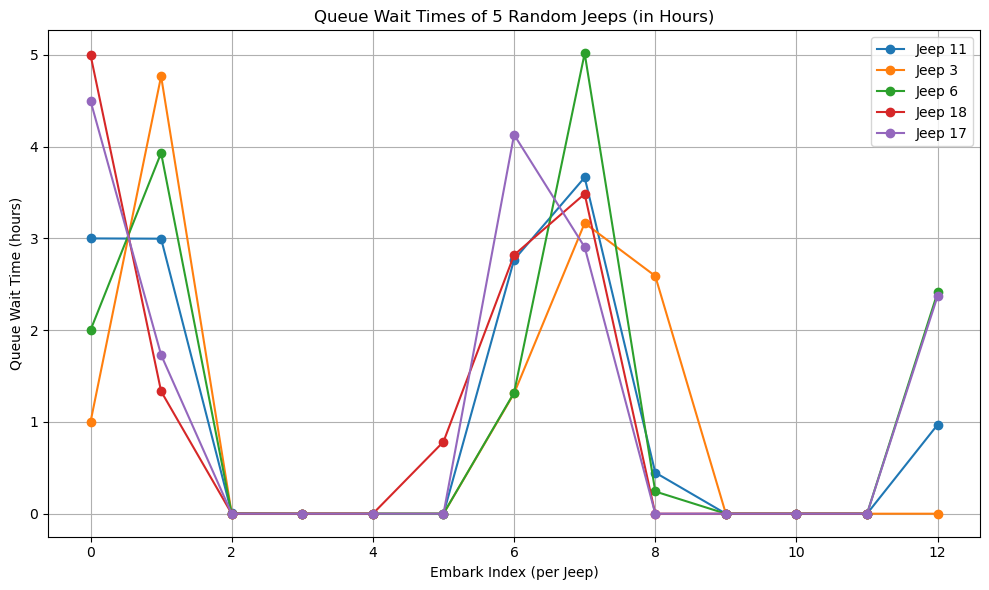

In [28]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0     [0.5, 5.5, 6.6, 7.38, 8.16, 8.94, 9.72, 14.93,...
1     [0.5, 5.5, 6.66, 7.43, 8.21, 8.99, 10.62, 13.9...
2     [1.0, 6.0, 6.78, 7.55, 8.33, 9.07, 10.11, 15.4...
3     [1.0, 6.0, 6.78, 7.55, 8.33, 9.07, 10.84, 14.4...
4     [1.5, 6.07, 6.85, 7.63, 8.41, 9.11, 10.46, 15....
5     [1.5, 6.06, 6.84, 7.61, 8.39, 9.1, 11.07, 14.9...
6     [2.0, 6.16, 6.94, 7.72, 8.5, 9.17, 10.95, 16.4...
7     [2.0, 6.12, 6.9, 7.68, 8.46, 9.14, 11.47, 15.4...
8     [2.5, 6.23, 7.01, 7.79, 8.56, 9.21, 11.27, 16....
9     [2.5, 6.18, 6.96, 7.73, 8.51, 9.17, 11.94, 15....
10    [3.0, 6.28, 7.05, 7.83, 8.61, 9.23, 11.66, 17....
11    [3.0, 6.23, 7.01, 7.79, 8.57, 9.21, 12.44, 16....
12    [3.5, 6.34, 7.12, 7.9, 8.67, 9.27, 11.98, 17.1...
13    [3.5, 6.32, 7.1, 7.88, 8.65, 9.26, 12.94, 16.9...
14    [4.0, 6.43, 7.21, 7.99, 8.77, 9.59, 12.48, 17....
15    [4.0, 6.41, 7.19, 7.96, 8.74, 9.31, 13.44, 17....
16    [4.5, 6.5, 7.28, 8.06, 8.84, 9.81, 12.98, 17.1...
17    [4.5, 6.46, 7.24, 8.02, 8.8, 9.35, 13.94, 

In [10]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0     [0.73, 5.73, 7.38, 8.16, 8.93, 9.43, 10.19, 15...
1     [0.73, 5.73, 7.43, 8.21, 8.99, 9.46, 11.08, 14...
2     [1.23, 6.78, 7.55, 8.33, 9.07, 9.53, 10.58, 15...
3     [1.23, 6.78, 7.55, 8.33, 9.07, 9.53, 11.31, 14...
4     [1.73, 6.85, 7.63, 8.41, 9.11, 9.58, 10.93, 16...
5     [1.73, 6.84, 7.61, 8.39, 9.1, 9.57, 11.54, 15....
6     [2.23, 6.94, 7.72, 8.5, 9.17, 9.63, 11.42, 17....
7     [2.23, 6.9, 7.68, 8.46, 9.14, 9.61, 11.94, 15....
8     [2.73, 7.01, 7.79, 8.56, 9.21, 9.67, 11.73, 17...
9     [2.73, 6.96, 7.73, 8.51, 9.17, 9.64, 12.26, 16...
10    [3.23, 7.05, 7.83, 8.61, 9.23, 9.7, 12.08, 17....
11    [3.23, 7.01, 7.79, 8.57, 9.21, 9.67, 12.73, 17...
12    [3.73, 7.12, 7.9, 8.67, 9.27, 9.74, 12.28, 17....
13    [3.73, 7.1, 7.88, 8.65, 9.26, 9.73, 13.23, 17....
14    [4.23, 7.21, 7.99, 8.77, 9.33, 10.06, 12.77, 1...
15    [4.23, 7.18, 7.96, 8.74, 9.31, 9.78, 13.73, 17...
16    [4.73, 7.28, 8.06, 8.84, 9.37, 10.28, 13.27, 1...
17    [4.73, 7.24, 8.02, 8.8, 9.35, 9.81, 14.23,

In [11]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0     2613
1     2860
2     2691
3     2860
4     2860
5     3081
6     2925
7     3146
8     2821
9     2977
10    2964
11    2834
12    2925
13    2821
14    2756
15    2925
16    2795
17    2938
18    2769
19    2964
Name: gross_profit, dtype: int64

In [12]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [13]:
jeep_df["gas_expense"]

0     1090.908
1     1090.908
2     1090.908
3     1090.908
4     1090.908
5     1090.908
6     1090.908
7     1090.908
8     1090.908
9     1090.908
10    1090.908
11    1090.908
12    1090.908
13    1090.908
14    1090.908
15    1090.908
16    1090.908
17    1090.908
18    1090.908
19    1090.908
Name: gas_expense, dtype: float64

In [14]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [15]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,0,0,0.0025,201,NaN,"[2639, 20639, 26563, 29364, 32165, 33939, 3667...","[1799, 19799, 23763, 26564, 29365, 32166, 3499...","[0, 2639, 20639, 26563, 29364, 32165, 33939, 3...","[1799, 17160, 3124, 1, 1, 1, 1056, 17086, 7311...","[0.5, 5.5, 6.6, 7.38, 8.16, 8.94, 9.72, 14.93,...","[0.73, 5.73, 7.38, 8.16, 8.93, 9.43, 10.19, 15...",2613,1090.908,1522.092
1,1,20,0,0,0.0025,220,NaN,"[2639, 20639, 26759, 29560, 32361, 34057, 3990...","[1799, 19799, 23959, 26760, 29561, 32362, 3822...","[0, 2639, 20639, 26759, 29560, 32361, 34057, 3...","[1799, 17160, 3320, 1, 1, 1, 4164, 10417, 1092...","[0.5, 5.5, 6.66, 7.43, 8.21, 8.99, 10.62, 13.9...","[0.73, 5.73, 7.43, 8.21, 8.99, 9.46, 11.08, 14...",2860,1090.908,1769.092
2,2,20,1,1,0.0025,207,4420|4422|4424,"[4439, 24396, 27197, 29998, 32639, 34320, 3808...","[3599, 21599, 24397, 27198, 29999, 32640, 3640...","[0, 4439, 24396, 27197, 29998, 32639, 34320, 3...","[3599, 17160, 1, 1, 1, 1, 2083, 17478, 5761, 1...","[1.0, 6.0, 6.78, 7.55, 8.33, 9.07, 10.11, 15.4...","[1.23, 6.78, 7.55, 8.33, 9.07, 9.53, 10.58, 15...",2691,1090.908,1600.092
3,3,20,0,0,0.0025,220,NaN,"[4439, 24396, 27197, 29998, 32639, 34320, 4071...","[3599, 21599, 24397, 27198, 29999, 32640, 3903...","[0, 4439, 24396, 27197, 29998, 32639, 34320, 4...","[3599, 17160, 1, 1, 1, 1, 4719, 11399, 9325, 1...","[1.0, 6.0, 6.78, 7.55, 8.33, 9.07, 10.84, 14.4...","[1.23, 6.78, 7.55, 8.33, 9.07, 9.53, 11.31, 14...",2860,1090.908,1769.092
4,4,20,1,1,0.0025,220,NaN,"[6239, 24669, 27470, 30271, 32803, 34484, 3934...","[5399, 21869, 24670, 27471, 30272, 32804, 3766...","[0, 6239, 24669, 27470, 30271, 32803, 34484, 3...","[5399, 15630, 1, 1, 1, 1, 3180, 18017, 2885, 1...","[1.5, 6.07, 6.85, 7.63, 8.41, 9.11, 10.46, 15....","[1.73, 6.85, 7.63, 8.41, 9.11, 9.58, 10.93, 16...",2860,1090.908,1769.092
5,5,20,0,0,0.0025,237,NaN,"[6239, 24610, 27411, 30212, 32767, 34448, 4153...","[5399, 21810, 24611, 27412, 30213, 32768, 3985...","[0, 6239, 24610, 27411, 30212, 32767, 34448, 4...","[5399, 15571, 1, 1, 1, 1, 5405, 12385, 7778, 1...","[1.5, 6.06, 6.84, 7.61, 8.39, 9.1, 11.07, 14.9...","[1.73, 6.84, 7.61, 8.39, 9.1, 9.57, 11.54, 15....",3081,1090.908,1990.092
6,6,20,1,1,0.0025,225,NaN,"[8039, 24989, 27790, 30591, 32995, 34676, 4110...","[7199, 22189, 24990, 27791, 30592, 32996, 3942...","[0, 8039, 24989, 27790, 30591, 32995, 34676, 4...","[7199, 14150, 1, 1, 1, 1, 4747, 18058, 872, 1,...","[2.0, 6.16, 6.94, 7.72, 8.5, 9.17, 10.95, 16.4...","[2.23, 6.94, 7.72, 8.5, 9.17, 9.63, 11.42, 17....",2925,1090.908,1834.092
7,7,20,0,0,0.0025,242,NaN,"[8039, 24842, 27643, 30444, 32907, 34588, 4297...","[7199, 22042, 24843, 27644, 30445, 32908, 4129...","[0, 8039, 24842, 27643, 30444, 32907, 34588, 4...","[7199, 14003, 1, 1, 1, 1, 6705, 12459, 6492, 1...","[2.0, 6.12, 6.9, 7.68, 8.46, 9.14, 11.47, 15.4...","[2.23, 6.9, 7.68, 8.46, 9.14, 9.61, 11.94, 15....",3146,1090.908,2055.092
8,8,20,1,1,0.0025,217,NaN,"[9839, 25227, 28028, 30829, 33138, 34819, 4224...","[8999, 22427, 25228, 28029, 30830, 33139, 4056...","[0, 9839, 25227, 28028, 30829, 33138, 34819, 4...","[8999, 12588, 1, 1, 1, 1, 5746, 18716, 1, 1, 1...","[2.5, 6.23, 7.01, 7.79, 8.56, 9.21, 11.27, 16....","[2.73, 7.01, 7.79, 8.56, 9.21, 9.67, 11.73, 17...",2821,1090.908,1730.092
9,9,20,0,0,0.0025,229,NaN,"[9839, 25038, 27839, 30640, 33024, 34705, 4411...","[8999, 22238, 25039, 27840, 30641, 33025, 4299...","[0, 9839, 25038, 27839, 30640, 33024, 34705, 4...","[8999, 12399, 1, 1, 1, 1, 8286, 13113, 3710, 1...","[2.5, 6.18, 6.96, 7.73, 8.51, 9.17, 11.94, 15....","[2.73, 6.96, 7.73, 8.51, 9.17, 9.64, 12.26, 16...",2977,1090.908,1886.092


In [16]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.09,0.09,0.5,0.73,0,0
1,1,0.15,0.15,0.5,0.73,0,0
2,2,0.35,0.35,0.5,0.73,1,1
3,3,0.36,0.36,0.5,0.73,0,0
4,4,0.40,0.40,0.5,0.73,1,1
...,...,...,...,...,...,...,...
4420,4420,23.80,23.80,0.0,0.00,2,1
4421,4421,23.84,23.84,0.0,0.00,12,0
4422,4422,23.86,23.86,0.0,0.00,2,1
4423,4423,23.91,23.91,0.0,0.00,12,0


In [17]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.09,0.09,0.50,0.73,0,0,0.64
1,1,0.15,0.15,0.50,0.73,0,0,0.58
2,2,0.35,0.35,0.50,0.73,1,1,0.38
3,3,0.36,0.36,0.50,0.73,0,0,0.37
4,4,0.40,0.40,0.50,0.73,1,1,0.33
...,...,...,...,...,...,...,...,...
4413,4413,23.41,23.41,23.72,23.97,0,1,0.56
4414,4414,23.43,23.43,23.60,23.86,10,0,0.43
4415,4415,23.45,23.45,23.60,23.86,10,0,0.41
4416,4416,23.53,23.53,23.72,23.97,0,1,0.44


In [18]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [19]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.09,0.09,0.5,0.73,0,0,0.64
1,1,0.15,0.15,0.5,0.73,0,0,0.58
3,3,0.36,0.36,0.5,0.73,0,0,0.37
8,8,1.02,1.02,1.5,1.73,4,0,0.71
9,9,1.08,1.08,1.5,1.73,4,0,0.65
...,...,...,...,...,...,...,...,...
4410,4410,23.17,23.17,23.6,23.86,10,0,0.69
4412,4412,23.32,23.32,23.6,23.86,10,0,0.54
4414,4414,23.43,23.43,23.6,23.86,10,0,0.43
4415,4415,23.45,23.45,23.6,23.86,10,0,0.41


In [20]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
2,2,0.35,0.35,0.50,0.73,1,1,0.38
4,4,0.40,0.40,0.50,0.73,1,1,0.33
5,5,0.53,0.53,1.00,1.23,3,1,0.70
6,6,0.66,0.66,1.00,1.23,3,1,0.57
7,7,0.80,0.80,1.00,1.23,3,1,0.43
...,...,...,...,...,...,...,...,...
4406,4406,23.07,23.07,23.22,23.47,19,1,0.40
4409,4409,23.14,23.14,23.22,23.47,19,1,0.33
4411,4411,23.31,23.31,23.72,23.97,0,1,0.66
4413,4413,23.41,23.41,23.72,23.97,0,1,0.56


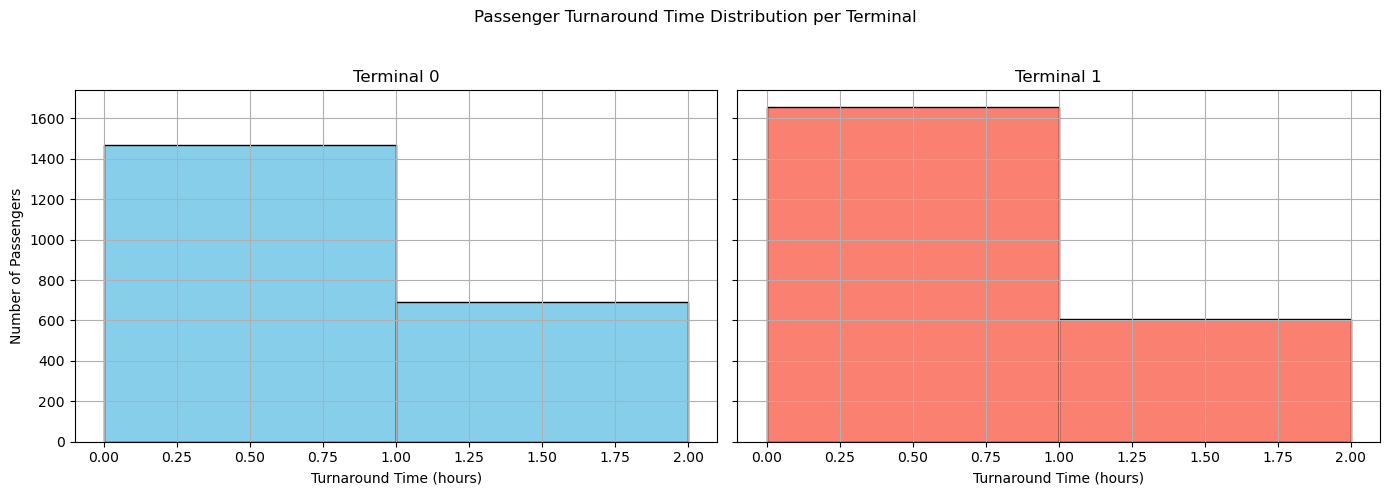

In [21]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

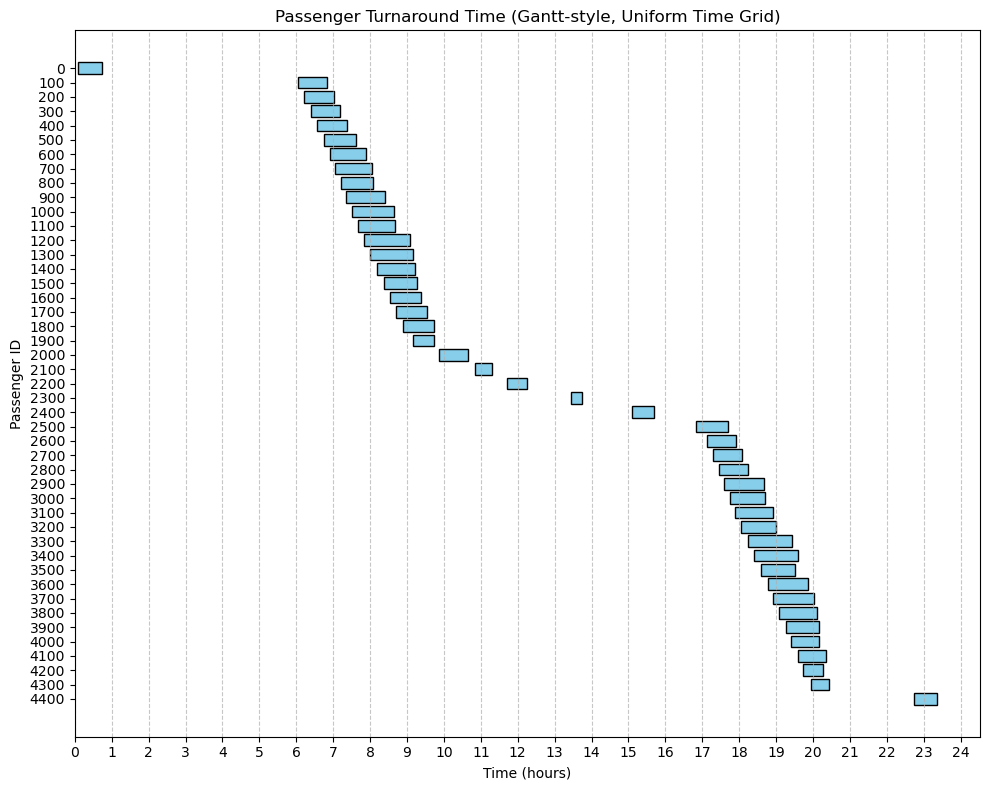

In [22]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

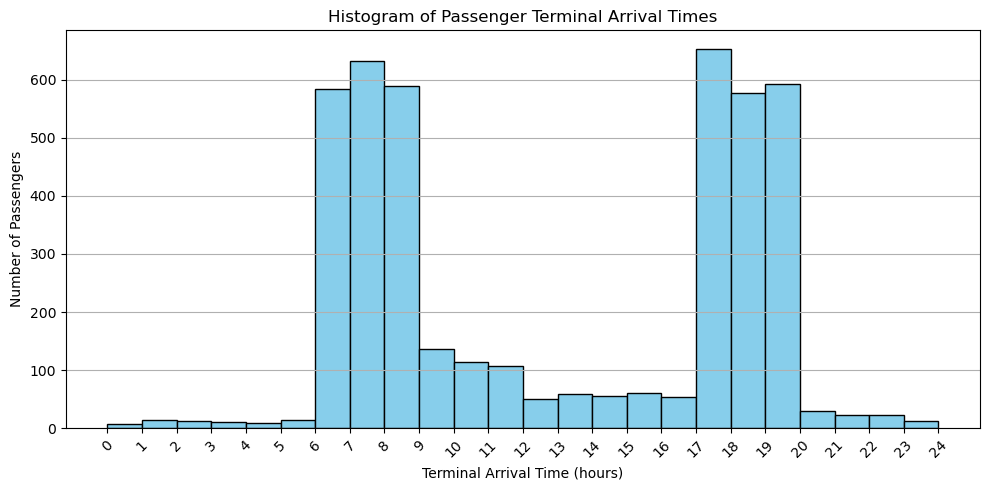

In [23]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()